# 03 · LSTM ทำนายระดับน้ำ X.44 ล่วงหน้า 1–5 วัน

```
ย้อนหลัง 30 วัน × 7 features ──► LSTM (hidden 32) ──► สรุปเป็นเวกเตอร์ 32 ค่า ─┐
 (ระยะจากตลิ่ง 6 สถานี + ฝน)                                                  ├──► Dropout ──► MLP ──► น้ำจะขึ้น/ลงเท่าไร h = 1…5
พยากรณ์ฝน t+1…t+h (5 ค่า) ────────────────────────────────────────────────────┘
                                                        ระดับทำนาย = ระดับวันนี้ + ค่าที่ทำนาย
```
- **LSTM** อ่านข้อมูลทีละวันตามลำดับเวลา จำแนวโน้ม เช่น "ต้นน้ำเริ่มขึ้นมา 2 วันแล้ว ฝนสะสมเยอะ"
- **พยากรณ์ฝน** เข้าหลัง LSTM เพราะเป็นข้อมูลอนาคต ไม่ใช่ส่วนของลำดับย้อนหลัง
- โมเดลเดียวทำนายทั้ง 5 วันพร้อมกัน
- **กันโมเดลจำข้อมูล (overfit):** dropout 0.3 + weight decay + **early stopping** (หยุดเมื่อ validation loss ไม่ดีขึ้น 15 epoch
  แล้วใช้ weight ของ epoch ที่ดีที่สุด)
- loss = MSE ที่ให้น้ำหนักวันน้ำสูง (≥ 3 ม.) มากขึ้น 5 เท่า เพราะวันแบบนี้มีน้อยแต่สำคัญที่สุด

โค้ดโมเดลอยู่ใน `mojito/lstm.py`

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy
import pandas
import torch

from mojito import config, evaluation, lstm, minimal

plt.rcParams.update({
    "font.family": ["Noto Sans Thai", "DejaVu Sans"],
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
torch.set_num_threads(6)

HORIZONS = minimal.HORIZONS
X44_BANK = config.BANK_LEVEL_M["X.44"]
FLOOD_M = evaluation.FLOOD_M  # 7.40 ม. น้ำท่วมพื้นที่ลุ่มต่ำ

table = pandas.read_parquet(config.DATA_DIR / "processed" / "minimal_daily.parquet")
FEATURES, RAIN_NEXT = minimal.FEATURES, minimal.RAIN_NEXT
days = {
    split: table.index[(table["split"] == split) & table["x44_max"].notna()]
    for split in ("train", "validation", "test")
}
print("features:", FEATURES)
print({split: len(d) for split, d in days.items()})

features: ['x44_bank', 'x90_bank', 'x173a_bank', 'x174_bank', 'sla007_bank', 'sla005_bank', 'rain']
{'train': 1734, 'validation': 273, 'test': 369}


## 1 · ข้อมูลที่ LSTM เห็นต่อ 1 ตัวอย่าง
ทุกวัน t สร้างหน้าต่างย้อนหลัง 30 วัน (t−29 … t) → 1 ตัวอย่าง (`lstm.make_sequences`)

In [2]:
sequences, rain_next, targets, ends = lstm.make_sequences(table, FEATURES, RAIN_NEXT, days["train"])
print(f"ลำดับย้อนหลัง : {sequences.shape}  = (จำนวนตัวอย่าง, 30 วัน, {len(FEATURES)} features)")
print(f"ฝนอนาคต      : {rain_next.shape}  = (จำนวนตัวอย่าง, h = 1…5)")
print(f"target       : {targets.shape}  = (จำนวนตัวอย่าง, น้ำขึ้น/ลง h = 1…5)")

sample_day = pandas.Timestamp("2024-11-27")
i = list(ends).index(sample_day)
pandas.DataFrame(sequences[i][-5:], columns=FEATURES,
                 index=pandas.date_range(end=sample_day, periods=5).date).round(2)

ลำดับย้อนหลัง : (1705, 30, 7)  = (จำนวนตัวอย่าง, 30 วัน, 7 features)
ฝนอนาคต      : (1705, 5)  = (จำนวนตัวอย่าง, h = 1…5)
target       : (1705, 5)  = (จำนวนตัวอย่าง, น้ำขึ้น/ลง h = 1…5)


,x44_bank,x90_bank,x173a_bank,x174_bank,sla007_bank,sla005_bank,rain
2024-11-23,-6.03,-6.34,-5.69,-4.04,-0.79,NaN,12.40
2024-11-24,-5.99,-6.51,-5.69,-3.94,-0.74,NaN,18.73
2024-11-25,-6.00,-6.45,-5.69,-3.97,-0.76,NaN,25.40
2024-11-26,-5.85,-5.70,-4.60,-2.69,-0.60,NaN,37.92
2024-11-27,-2.24,-0.77,-0.10,0.42,-0.17,NaN,82.83


## 2 · เทรน
hyperparameter ตั้งค่าคงที่ (ข้อมูลน้อย ไม่ค้นหา grid) · เทรนโมเดลเดียว (seed 0) สูงสุด 200 epoch
แต่ละ epoch: เทรนด้วยข้อมูล train ทั้งหมด (ทีละ batch 64 ตัวอย่าง) แล้ววัด loss บน validation
ถ้า validation loss ไม่ดีขึ้น 15 epoch ติดกัน → หยุด และย้อนกลับไปใช้ weight ของ epoch ที่ validation loss ต่ำสุด

In [3]:
PARAMS = {"hidden": 32, "dropout": 0.3, "lr": 1e-3, "high_water_weight": 4.0}
MAX_EPOCHS, PATIENCE, SEED = 200, 15, 0

model = lstm.LSTMForecaster(FEATURES, RAIN_NEXT, seed=SEED, **PARAMS).fit(
    table, days["train"], epochs=MAX_EPOCHS,
    validation_table=table, validation_days=days["validation"], patience=PATIENCE,
)
print(f"หยุดที่ epoch {len(model.history)}, ใช้ weight ของ epoch {model.best_epoch}")

หยุดที่ epoch 27, ใช้ weight ของ epoch 12


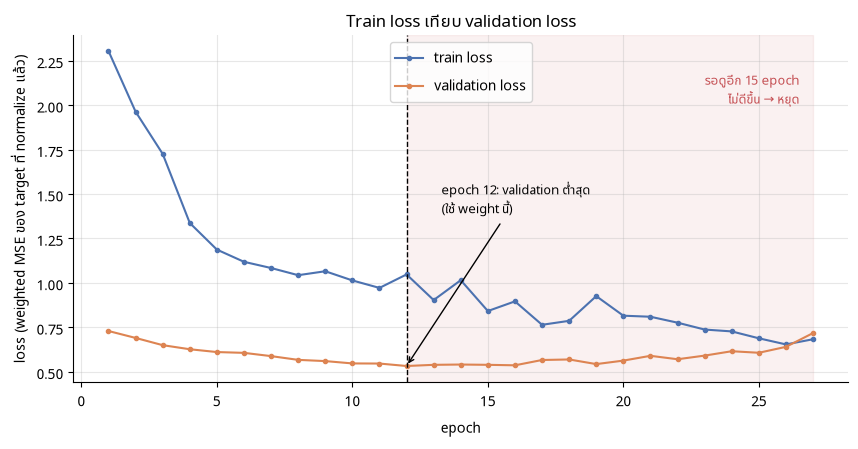

In [4]:
epochs = range(1, len(model.history) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(epochs, model.train_history, color="#4c72b0", marker=".", label="train loss")
ax.plot(epochs, model.history, color="#dd8452", marker=".", label="validation loss")
ax.axvline(model.best_epoch, color="k", ls="--", lw=1)
ax.annotate(f"epoch {model.best_epoch}: validation ต่ำสุด\n(ใช้ weight นี้)",
            (model.best_epoch, min(model.history)), xytext=(25, 110), textcoords="offset points",
            arrowprops={"arrowstyle": "->"}, fontsize=9)
ax.axvspan(model.best_epoch, len(model.history), color="#c44e52", alpha=0.08)
ax.text(len(model.history) - 0.5, max(model.train_history) * 0.95,
        f"รอดูอีก {PATIENCE} epoch\nไม่ดีขึ้น → หยุด", ha="right", va="top", fontsize=9, color="#c44e52")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (weighted MSE ของ target ที่ normalize แล้ว)")
ax.set_title("Train loss เทียบ validation loss")
ax.legend(loc="upper center")
plt.show()

- **train loss** ลดลงเรื่อยๆ เพราะโมเดลปรับตัวเข้าหาข้อมูล train
- **validation loss** ลดลงช่วงแรก แล้วหยุดลด/เริ่มเพิ่ม = โมเดลเริ่มจำข้อมูล train แทนที่จะเรียนรูปแบบทั่วไป (**overfit**)
- early stopping เลือก epoch ที่ validation ต่ำสุด (เส้นประ) — ช่วงสีแดงคือ epoch ที่เทรนต่อแต่ไม่ได้ใช้
- validation loss ต่ำกว่า train loss ได้ เพราะ validation (ม.ค.–ก.ย. 2568) ไม่มีวันน้ำหลากที่ error ใหญ่
  และตอนวัด train loss ยังเปิด dropout อยู่

## 3 · ผลบน test (ต.ค. 2568 – ปัจจุบัน)
เทียบกับ **persistence** = เดาว่า "อีก h วันน้ำจะเท่าวันนี้" ซึ่งเป็นเกณฑ์ขั้นต่ำที่โมเดลต้องชนะ
- **MAE** = คลาดเฉลี่ยกี่เมตร · **RMSE** = คล้าย MAE แต่ลงโทษการพลาดครั้งใหญ่มากกว่า (ยกกำลังสองก่อนเฉลี่ย)
- **ทุกวัน:** วันน้ำปกติเป็นส่วนใหญ่ · **วันน้ำหลาก:** เฉพาะวันที่ระดับจริง ≥ 4 ม. — ตัวชี้วัดหลัก
- **เตือนถูก / เตือนผิด:** ทำนาย ≥ 7.40 ม. (ท่วมพื้นที่ลุ่มต่ำ) ตรงกับวันที่ท่วมจริงกี่วัน

In [5]:
def metrics(pred, frame, h):
    """MAE / RMSE over all days and high-water days, plus 7.40 m alert hits."""
    result = evaluation.scores(pred, frame, h)
    error = (pred - frame[f"target_h{h}"]).dropna()
    high = frame.loc[error.index, f"target_h{h}"] >= evaluation.HIGH_WATER_M
    result["RMSE ทุกวัน"] = numpy.sqrt((error ** 2).mean())
    result["RMSE วันน้ำหลาก"] = numpy.sqrt((error[high] ** 2).mean())
    return result


prediction = {split: model.predict(table, days[split]) for split in ("validation", "test")}
test = table.loc[days["test"]]

rows = []
for h in HORIZONS:
    for name, pred in [("persistence", evaluation.persistence(test, h)), ("LSTM", prediction["test"][f"h{h}"])]:
        rows.append({"h": h, "model": name, **metrics(pred, test, h)})
results = pandas.DataFrame(rows)
METRICS = ["MAE ทุกวัน", "RMSE ทุกวัน", "MAE วันน้ำหลาก", "RMSE วันน้ำหลาก", "เตือนถูก", "เตือนผิด"]
results.set_index(["model", "h"])[METRICS].unstack("h").round(2).rename_axis(columns=["", "h (วัน)"])

MAE ทุกวัน                         RMSE ทุกวัน                    \
h (วัน)              1     2     3     4     5           1     2     3     4   
model                                                                          
LSTM              0.15  0.25  0.33  0.40  0.45        0.26  0.42  0.56  0.73   
persistence       0.14  0.23  0.30  0.35  0.39        0.32  0.56  0.77  0.97   

                   ... เตือนถูก             เตือนผิด              
h (วัน)         5  ...        1  2  3  4  5        1  2  3  4  5  
model              ...                                            
LSTM         0.87  ...        5  5  4  2  2        0  1  2  2  2  
persistence  1.13  ...        5  4  3  2  1        1  2  3  4  5  

[2 rows x 30 columns]

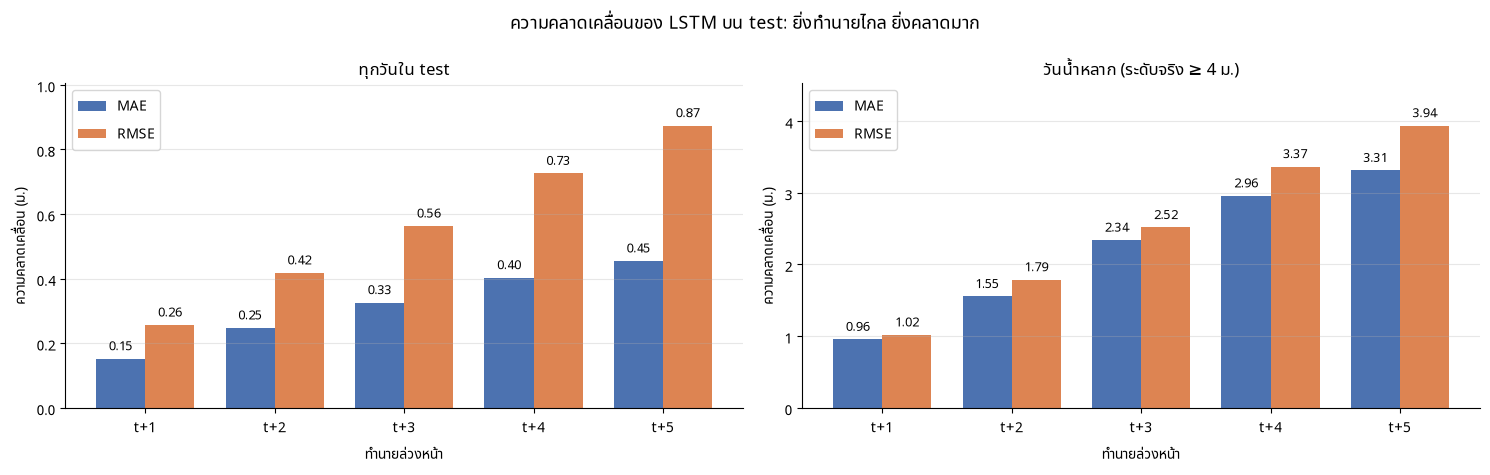

In [6]:
lstm_scores = results[results["model"] == "LSTM"].set_index("h")
METRIC_COLORS = {"MAE": "#4c72b0", "RMSE": "#dd8452"}
x = numpy.arange(len(HORIZONS))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (group, title) in zip(axes, [("ทุกวัน", "ทุกวันใน test"), ("วันน้ำหลาก", "วันน้ำหลาก (ระดับจริง ≥ 4 ม.)")]):
    for k, (metric, color) in enumerate(METRIC_COLORS.items()):
        bars = ax.bar(x + (k - 0.5) * width, lstm_scores[f"{metric} {group}"], width, color=color, label=metric)
        ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)
    ax.set_xticks(x, [f"t+{h}" for h in HORIZONS])
    ax.set_xlabel("ทำนายล่วงหน้า")
    ax.set_ylabel("ความคลาดเคลื่อน (ม.)")
    ax.set_title(title)
    ax.margins(y=0.15)
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper left")
fig.suptitle("ความคลาดเคลื่อนของ LSTM บน test: ยิ่งทำนายไกล ยิ่งคลาดมาก", fontsize=13)
plt.tight_layout()
plt.show()

- ยิ่งทำนายล่วงหน้าไกล ความคลาดเคลื่อนยิ่งมาก เพราะต้องพึ่งพยากรณ์ฝนซึ่งต่ำกว่าจริง
- **RMSE > MAE** เสมอ เพราะ RMSE ยกกำลังสองก่อนเฉลี่ย การพลาดครั้งใหญ่ (เช่นช่วงพีค) จึงดึงค่าขึ้นมาก
  ถ้า RMSE สูงกว่า MAE มาก = มีบางวันที่พลาดหนัก

## 4 · เหตุการณ์น้ำท่วม พ.ย. 2568
เส้นทำนายถูกเลื่อนไปที่ **วันที่ถูกทำนาย** (ไม่ใช่วันที่ออกพยากรณ์) เพื่อเทียบกับระดับจริงวันเดียวกัน
แกนขวาเป็นระยะจากตลิ่ง X.44

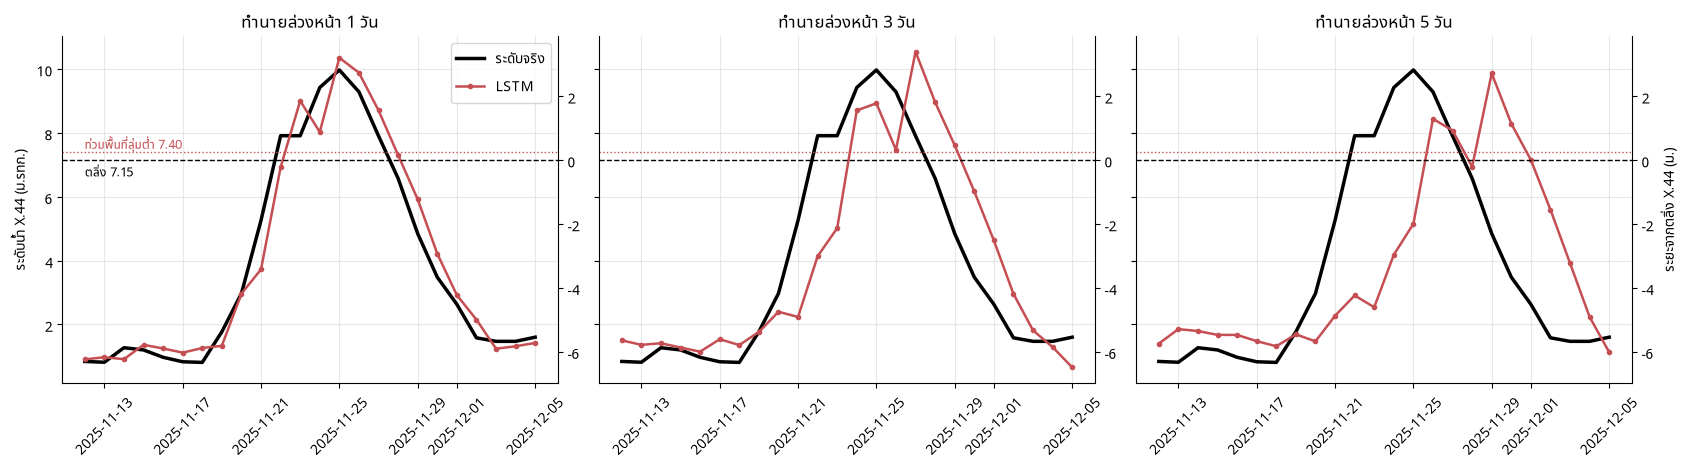

In [7]:
event = slice("2025-11-12", "2025-12-05")
actual = table["x44_max"].loc[event]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, h in zip(axes, (1, 3, 5)):
    shifted = prediction["test"][f"h{h}"].copy()
    shifted.index = shifted.index + pandas.Timedelta(days=h)
    ax.plot(actual.index, actual, color="k", lw=2.5, label="ระดับจริง")
    ax.plot(shifted.loc[event].index, shifted.loc[event], color="#c44e52", lw=1.8, marker=".", label="LSTM")
    ax.axhline(X44_BANK, color="k", ls="--", lw=1)
    ax.axhline(FLOOD_M, color="#c44e52", ls=":", lw=1)
    ax.set_title(f"ทำนายล่วงหน้า {h} วัน")
    ax.tick_params(axis="x", rotation=45)
    right = ax.secondary_yaxis("right", functions=(lambda y: y - X44_BANK, lambda y: y + X44_BANK))
    if h == 5:
        right.set_ylabel("ระยะจากตลิ่ง X.44 (ม.)")
axes[0].set_ylabel("ระดับน้ำ X.44 (ม.รทก.)")
axes[0].text(actual.index[0], X44_BANK - 0.1, "ตลิ่ง 7.15", fontsize=9, va="top")
axes[0].text(actual.index[0], FLOOD_M + 0.1, "ท่วมพื้นที่ลุ่มต่ำ 7.40", fontsize=9, color="#c44e52")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

In [8]:
# ตารางรายวันช่วงพีค: ทำนายเมื่อ h วันก่อน เทียบระดับจริง (ระยะจากตลิ่ง, ม.)
peak_days = pandas.date_range("2025-11-20", "2025-11-29")
peak_table = pandas.DataFrame({"จริง": table["x44_max"].reindex(peak_days) - X44_BANK})
for h in (1, 3, 5):
    shifted = prediction["test"][f"h{h}"].copy()
    shifted.index = shifted.index + pandas.Timedelta(days=h)
    peak_table[f"ทำนายล่วงหน้า {h} วัน"] = shifted.reindex(peak_days) - X44_BANK
peak_table.index = peak_table.index.date
peak_table.round(2)

,จริง,ทำนายล่วงหน้า 1 วัน,ทำนายล่วงหน้า 3 วัน,ทำนายล่วงหน้า 5 วัน
2025-11-20,-4.18,-4.19,-4.75,-5.68
2025-11-21,-1.89,-3.42,-4.92,-4.88
2025-11-22,0.76,-0.23,-3.02,-4.24
2025-11-23,0.76,1.85,-2.13,-4.61
2025-11-24,2.27,0.87,1.55,-2.97
2025-11-25,2.82,3.20,1.78,-2.00
2025-11-26,2.13,2.73,0.32,1.29
2025-11-27,0.75,1.55,3.39,0.92
2025-11-28,-0.58,0.15,1.81,-0.21
2025-11-29,-2.31,-1.23,0.46,2.71


## 5 · บันทึกโมเดลให้เว็บ
เว็บ (`mojito/web`) ใช้โมเดลตัวนี้ตัวเดียวกัน จึงบันทึก 3 อย่างลง `data/models/`
- `x44_lstm.joblib` — โมเดลที่เทรนแล้ว (รวมตัว standardise ของ input)
- `x44_lstm.json` — features, ตัวคูณแก้ bias GFS (ใช้กับพยากรณ์ฝนล่าสุดในโหมดข้อมูลสด) และช่วงแบ่งข้อมูล
- `uncertainty.json` คีย์ `lstm` — RMSE บน test แยกตามระดับที่ทำนาย (< 4 ม. / ≥ 4 ม.) ใช้เป็นช่วง ± ในกราฟเว็บ
  และใช้คำนวณความน่าจะเป็นที่แต่ละโซนจะท่วม ต้องใช้ test เพราะ validation ไม่มีวันน้ำสูงเลย
  (ช่วงนี้จึงวัดจากข้อมูลชุดเดียวกับที่ใช้รายงานผล)

In [9]:
models_dir = config.DATA_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(model, models_dir / "x44_lstm.joblib")

manifest = {
    "features": FEATURES,
    "rain_next": RAIN_NEXT,
    "gfs_model": minimal.GFS_MODEL,
    "gfs_scale": minimal.gfs_bias_scale(table),
    "params": PARAMS,
    "best_epoch": model.best_epoch,
    "train_end": minimal.TRAIN_END,
    "validation_end": minimal.VALIDATION_END,
}
(models_dir / "x44_lstm.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2))

uncertainty_path = models_dir / "uncertainty.json"
uncertainty = json.loads(uncertainty_path.read_text()) if uncertainty_path.exists() else {}
uncertainty["split_stage_m"] = evaluation.HIGH_WATER_M
uncertainty["lstm"] = {
    str(h): evaluation.stage_split_rmse(prediction["test"][f"h{h}"], test, h) for h in HORIZONS
}
uncertainty_path.write_text(json.dumps(uncertainty, ensure_ascii=False, indent=2))
pandas.DataFrame(uncertainty["lstm"]).T.rename_axis("h").rename(
    columns={"low": "σ ระดับ < 4 ม.", "high": "σ ระดับ ≥ 4 ม.", "high_days": "จำนวนวันที่ทำนาย ≥ 4 ม."})

,σ ระดับ < 4 ม.,σ ระดับ ≥ 4 ม.,จำนวนวันที่ทำนาย ≥ 4 ม.
h,,,
1,0.216,0.913,9.0
2,0.310,1.819,9.0
3,0.400,2.430,10.0
4,0.546,3.094,9.0
5,0.631,3.893,9.0


## 6 · สรุป
**LSTM + ระยะจากตลิ่ง + พยากรณ์ฝน ทำนายช่วงน้ำหลากได้ดีกว่า persistence ทุก horizon**

| ทำนายล่วงหน้า | t+1 | t+2 | t+3 | t+4 | t+5 |
|---|---|---|---|---|---|
| MAE วันน้ำหลาก LSTM / persistence (ม.) | **0.96** / 1.35 | **1.55** / 2.51 | **2.34** / 3.61 | **2.96** / 4.24 | **3.31** / 4.78 |
| RMSE วันน้ำหลาก LSTM / persistence (ม.) | **1.02** / 1.56 | **1.79** / 2.81 | **2.52** / 3.93 | **3.37** / 4.80 | **3.94** / 5.43 |
| เตือน ≥ 7.40 ม. ถูก (จาก 6 วัน) LSTM / persistence | 5 / 5 | **5** / 4 | **4** / 3 | 2 / 2 | **2** / 1 |
| เตือนผิด LSTM / persistence | **0** / 1 | **1** / 2 | **2** / 3 | **2** / 4 | **2** / 5 |

- **ล่วงหน้า 1 วัน** ตามน้ำขึ้นได้ใกล้เคียงจริง รวมถึงพีค 9.97 ม. ที่สูงกว่าทุกอย่างใน train (เพราะทำนายการเปลี่ยนแปลง)
- **ล่วงหน้า 3–5 วัน** เห็นว่าน้ำจะขึ้น แต่ทำนายพีคต่ำและช้ากว่าจริง เพราะพยากรณ์ฝน GFS ให้ฝนหนักน้อยกว่าจริงมาก
- **การเตือน ≥ 7.40 ม.** เตือนถูกเท่าหรือมากกว่า persistence ทุก horizon และเตือนผิดน้อยกว่า (รวม 7 vs 15 ครั้ง)
- **ทุกวัน:** MAE แย่กว่า persistence เล็กน้อย (0.15–0.45 vs 0.14–0.39 ม.) แต่ RMSE ดีกว่า (0.26–0.87 vs 0.32–1.13 ม.)
  = วันน้ำปกติคลาดเล็กๆ บ่อยกว่า แต่พลาดครั้งใหญ่น้อยกว่า
- **early stopping** หยุดที่ epoch 27 และใช้ weight ของ epoch 12: หลังจากนั้น train loss ลดต่อแต่ validation loss ไม่ลด = overfit

**ข้อจำกัด**
1. น้ำท่วมใหญ่ใน test มีแค่ครั้งเดียว (6 วันท่วม) ตัวเลขจึงแกว่งได้มาก และเทรนด้วย seed เดียว ผลอาจต่างไปตาม seed
2. validation (ม.ค.–ก.ย. 2568) ไม่มีวันน้ำหลาก — early stopping ตัดสินจากวันปกติ
3. train ใช้ฝนอนาคตที่ตกจริง แต่ test ใช้พยากรณ์ซึ่งต่ำกว่าจริง → โมเดลเห็นฝนน้อยกว่าที่เรียนมา
4. SLA005 ขาดข้อมูลช่วง 2567 – ก.ย. 2568